<a href="https://colab.research.google.com/github/marcelcerri/Python_biocientistas_unesp/blob/main/Aula_06_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biblioteca Pandas

In [1]:
# 1. Importar a biblioteca. É uma convenção universal dar o apelido 'pd'.
import pandas as pd

# 2. Criar os dados usando um dicionário
# As chaves do dicionário serão os nomes das colunas.
# As listas de valores serão os dados de cada coluna.
dados_laboratorio = {
    'Amostra_ID': ['A01', 'A02', 'A03', 'A04', 'A05'],
    'Tipo_Celular': ['HeLa', 'HeLa', 'Fibroblasto', 'HeLa', 'Fibroblasto'],
    'pH_Meio': [7.4, 7.3, 7.4, 7.2, 7.3],
    'Contagem_Celular': [150, 180, 95, 210, 110]
}

# 3. Criar o DataFrame a partir do dicionário
df = pd.DataFrame(dados_laboratorio)

# 4. Exibir o DataFrame
print("Nosso primeiro DataFrame:")
print(df)

Nosso primeiro DataFrame:
  Amostra_ID Tipo_Celular  pH_Meio  Contagem_Celular
0        A01         HeLa      7.4               150
1        A02         HeLa      7.3               180
2        A03  Fibroblasto      7.4                95
3        A04         HeLa      7.2               210
4        A05  Fibroblasto      7.3               110


In [2]:
# Ver as 5 primeiras linhas (ótimo para tabelas grandes)
print("\nVerificando as primeiras linhas com .head():")
print(df.head())


Verificando as primeiras linhas com .head():
  Amostra_ID Tipo_Celular  pH_Meio  Contagem_Celular
0        A01         HeLa      7.4               150
1        A02         HeLa      7.3               180
2        A03  Fibroblasto      7.4                95
3        A04         HeLa      7.2               210
4        A05  Fibroblasto      7.3               110


In [3]:
# Obter um resumo técnico do DataFrame (tipos de dados, valores não-nulos)
print("\nResumo técnico com .info():")
df.info()


Resumo técnico com .info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Amostra_ID        5 non-null      object 
 1   Tipo_Celular      5 non-null      object 
 2   pH_Meio           5 non-null      float64
 3   Contagem_Celular  5 non-null      int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 292.0+ bytes


In [4]:
# Obter estatísticas descritivas básicas das colunas numéricas
print("\nEstatísticas básicas com .describe():")
print(df.describe())


Estatísticas básicas com .describe():
        pH_Meio  Contagem_Celular
count  5.000000          5.000000
mean   7.320000        149.000000
std    0.083666         47.749346
min    7.200000         95.000000
25%    7.300000        110.000000
50%    7.300000        150.000000
75%    7.400000        180.000000
max    7.400000        210.000000


In [5]:
# Ver o formato do DataFrame (linhas, colunas)
print(f"\nFormato do DataFrame (linhas, colunas): {df.shape}")


Formato do DataFrame (linhas, colunas): (5, 4)


In [6]:
# a) Selecionar uma única coluna (retorna uma Series)
print("\nSelecionando a coluna 'Tipo_Celular':")
print(df['Tipo_Celular'])


Selecionando a coluna 'Tipo_Celular':
0           HeLa
1           HeLa
2    Fibroblasto
3           HeLa
4    Fibroblasto
Name: Tipo_Celular, dtype: object


In [7]:
# b) Selecionar múltiplas colunas (retorna um novo DataFrame)
print("\nSelecionando as colunas 'Amostra_ID' e 'Contagem_Celular':")
print(df[['Amostra_ID', 'Contagem_Celular']])


Selecionando as colunas 'Amostra_ID' e 'Contagem_Celular':
  Amostra_ID  Contagem_Celular
0        A01               150
1        A02               180
2        A03                95
3        A04               210
4        A05               110


In [8]:
# c) Filtrar linhas com base em uma condição (MUITO PODEROSO!)
# Vamos encontrar todas as amostras que são do tipo 'HeLa'.
print("\nFiltrando apenas as amostras do tipo 'HeLa':")
df_hela = df.loc[df['Tipo_Celular'] == 'HeLa']
print(df_hela)


Filtrando apenas as amostras do tipo 'HeLa':
  Amostra_ID Tipo_Celular  pH_Meio  Contagem_Celular
0        A01         HeLa      7.4               150
1        A02         HeLa      7.3               180
3        A04         HeLa      7.2               210


In [9]:
# Outro filtro: amostras com contagem celular acima de 120.
print("\nFiltrando amostras com contagem celular > 120:")
df_alta_contagem = df.loc[df['Contagem_Celular'] > 120]
print(df_alta_contagem)


Filtrando amostras com contagem celular > 120:
  Amostra_ID Tipo_Celular  pH_Meio  Contagem_Celular
0        A01         HeLa      7.4               150
1        A02         HeLa      7.3               180
3        A04         HeLa      7.2               210


In [10]:
# a) Adicionar uma nova coluna
# Vamos adicionar uma coluna que indica se a contagem foi 'Alta' ou 'Baixa'.
# Usaremos uma função do NumPy para isso.
import numpy as np
df['Classificacao_Contagem'] = np.where(df['Contagem_Celular'] > 150, 'Alta', 'Baixa')
print("\nDataFrame com a nova coluna de classificação:")
print(df)


DataFrame com a nova coluna de classificação:
  Amostra_ID Tipo_Celular  pH_Meio  Contagem_Celular Classificacao_Contagem
0        A01         HeLa      7.4               150                  Baixa
1        A02         HeLa      7.3               180                   Alta
2        A03  Fibroblasto      7.4                95                  Baixa
3        A04         HeLa      7.2               210                   Alta
4        A05  Fibroblasto      7.3               110                  Baixa


In [11]:
# b) Ordenar o DataFrame por uma coluna
print("\nDataFrame ordenado pela contagem celular (do maior para o menor):")
df_ordenado = df.sort_values(by='Contagem_Celular', ascending=False)
print(df_ordenado)


DataFrame ordenado pela contagem celular (do maior para o menor):
  Amostra_ID Tipo_Celular  pH_Meio  Contagem_Celular Classificacao_Contagem
3        A04         HeLa      7.2               210                   Alta
1        A02         HeLa      7.3               180                   Alta
0        A01         HeLa      7.4               150                  Baixa
4        A05  Fibroblasto      7.3               110                  Baixa
2        A03  Fibroblasto      7.4                95                  Baixa


In [12]:
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn é ótimo para gráficos estatísticos

# Copie e cole todo o texto do CSV aqui
dados_csv = """Patient_ID,Group,Gender,Age,Biomarker_Initial,Biomarker_Final,Reported_Side_Effect
P001,Placebo,Female,55,12.5,12.8,No
P002,Drug A,Male,62,15.1,11.5,Yes
P003,Drug B,Male,48,11.8,7.1,No
P004,Placebo,Male,68,16.2,17.1,No
P005,Drug A,Female,51,14.5,10.2,No
P006,Drug B,Female,59,13.9,8.5,Yes
P007,Placebo,Female,61,14.8,14.5,Yes
P008,Drug A,Male,53,13.2,9.8,No
P009,Drug B,Male,65,15.8,9.1,Yes
P010,Placebo,Male,57,13.5,14.0,No
P011,Drug A,Female,60,16.0,12.1,Yes
P012,Drug B,Female,50,12.1,7.5,No
P013,Placebo,Female,63,15.5,15.8,No
P014,Drug A,Male,58,14.9,11.2,No
P015,Drug B,Male,56,13.3,8.0,No
P016,Placebo,Male,52,12.9,13.5,No
P017,Drug A,Female,64,16.5,12.5,Yes
P018,Drug B,Female,49,11.5,6.9,No
P019,Placebo,Male,66,16.8,16.5,No
P020,Drug A,Male,54,14.1,10.8,No
P021,Drug B,Male,61,15.2,8.8,Yes
P022,Placebo,Female,58,14.2,14.8,Yes
P023,Drug A,Female,57,15.3,11.8,No
P024,Drug B,Female,53,12.8,7.9,No
P025,Placebo,Male,60,15.0,15.2,No
P026,Drug A,Male,63,16.1,12.3,Yes
P027,Drug B,Male,51,12.5,7.7,No
P028,Placebo,Female,56,13.8,14.1,No
P029,Drug A,Female,59,15.7,11.9,No
P030,Drug B,Female,55,13.1,8.2,Yes
"""

# Carregar os dados usando read_csv
df = pd.read_csv(StringIO(dados_csv))

# Inspeção inicial
print("Primeiras 5 linhas:")
print(df.head())
print("\nInformações sobre o DataFrame:")
df.info()

Primeiras 5 linhas:
  Patient_ID    Group  Gender  Age  Biomarker_Initial  Biomarker_Final  \
0       P001  Placebo  Female   55               12.5             12.8   
1       P002   Drug A    Male   62               15.1             11.5   
2       P003   Drug B    Male   48               11.8              7.1   
3       P004  Placebo    Male   68               16.2             17.1   
4       P005   Drug A  Female   51               14.5             10.2   

  Reported_Side_Effect  
0                   No  
1                  Yes  
2                   No  
3                   No  
4                   No  

Informações sobre o DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            30 non-null     object 
 1   Group                 30 non-null     object 
 2   Gender                30 non-null     obje

In [13]:
nome_do_arquivo = 'dados_trat.csv'
df = pd.read_csv(nome_do_arquivo)
print(df)

   Patient_ID    Group  Gender  Age  Biomarker_Initial  Biomarker_Final  \
0        P001  Placebo  Female   55               12.5             12.8   
1        P002   Drug A    Male   62               15.1             11.5   
2        P003   Drug B    Male   48               11.8              7.1   
3        P004  Placebo    Male   68               16.2             17.1   
4        P005   Drug A  Female   51               14.5             10.2   
5        P006   Drug B  Female   59               13.9              8.5   
6        P007  Placebo  Female   61               14.8             14.5   
7        P008   Drug A    Male   53               13.2              9.8   
8        P009   Drug B    Male   65               15.8              9.1   
9        P010  Placebo    Male   57               13.5             14.0   
10       P011   Drug A  Female   60               16.0             12.1   
11       P012   Drug B  Female   50               12.1              7.5   
12       P013  Placebo  F


Mudança média no biomarcador por grupo:
Group
Drug A    -3.73
Drug B    -5.23
Placebo    0.31
Name: Biomarker_Change, dtype: float64


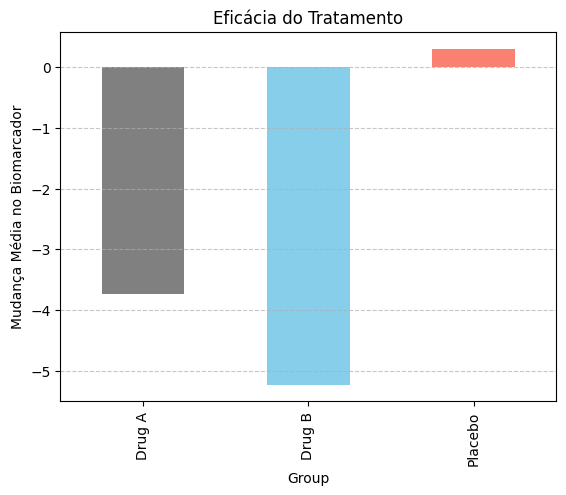

In [14]:
# Criar uma nova coluna com a mudança no biomarcador
df['Biomarker_Change'] = df['Biomarker_Final'] - df['Biomarker_Initial']

# Usar groupby() para calcular a média da mudança por grupo
media_mudanca_por_grupo = df.groupby('Group')['Biomarker_Change'].mean()

print("\nMudança média no biomarcador por grupo:")
print(media_mudanca_por_grupo)

# Vamos visualizar isso com um gráfico de barras
media_mudanca_por_grupo.plot(kind='bar',
                             title='Eficácia do Tratamento',
                             ylabel='Mudança Média no Biomarcador',
                             color=['gray', 'skyblue', 'salmon'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Contagem de Efeitos Colaterais por Grupo:
Reported_Side_Effect  No  Yes
Group                        
Drug A                 6    4
Drug B                 6    4
Placebo                8    2


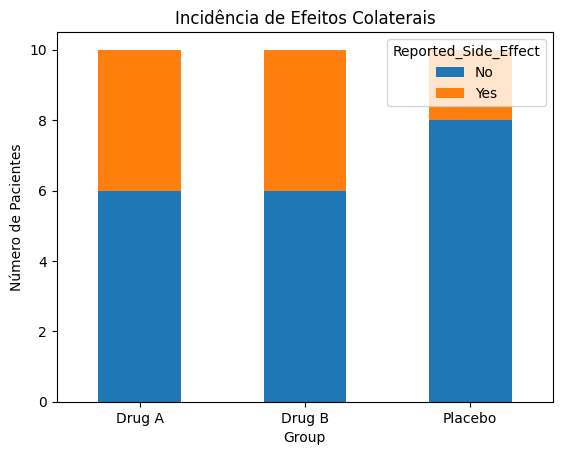

In [15]:
# Usar crosstab para criar uma tabela de contagem de efeitos colaterais por grupo
contagem_efeitos = pd.crosstab(df['Group'], df['Reported_Side_Effect'])

print("\nContagem de Efeitos Colaterais por Grupo:")
print(contagem_efeitos)

# Visualizar com um gráfico de barras empilhadas
contagem_efeitos.plot(kind='bar', stacked=True,
                      title='Incidência de Efeitos Colaterais',
                      ylabel='Número de Pacientes')
plt.xticks(rotation=0) # Mantém os nomes dos grupos na horizontal
plt.show()

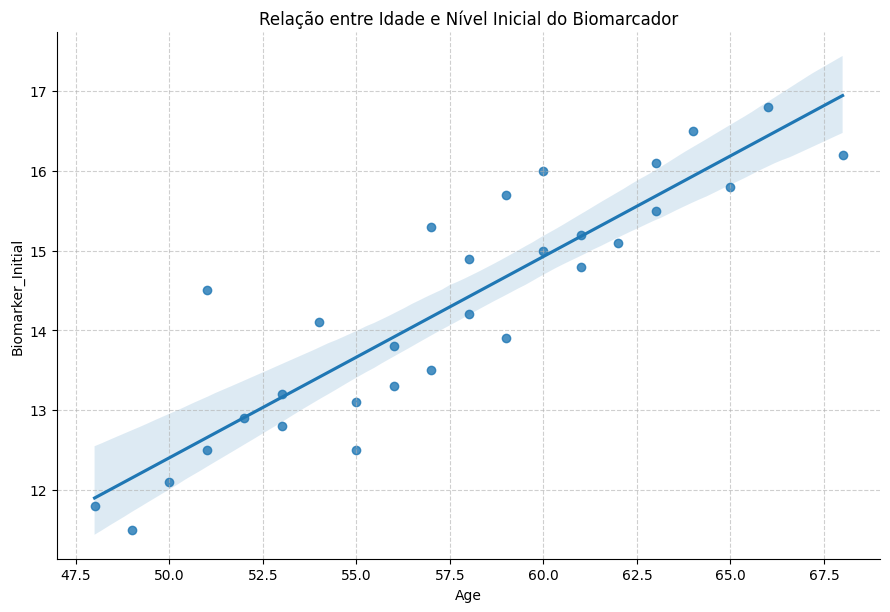

In [16]:
# Usar um gráfico de dispersão (scatter plot) para visualizar a relação
sns.lmplot(x='Age', y='Biomarker_Initial', data=df,
           height=6, aspect=1.5)
plt.title('Relação entre Idade e Nível Inicial do Biomarcador')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()